# FABN SAP Optimizer — Phase 2: Daily Dynamic Re-Optimization Backtest

Tests whether **daily dynamic re-optimization beats static buy-and-hold** under statutory (book-yield) economics, over 498 trading days (Mar 2024 – Feb 2026), starting from cash on day 1.

---

## Trade decision (`solve_day`) — runs once per optimization day

Choose buys $b_i\ge0$, sells $0\le s_i\le h^{prev}_i$, and swap notionals $v_k\ge0$:

$$
\max_{b,s,v}\;
T\!\sum_i\!\big[(h^{prev}_i-s_i)(y^{bk}_i-r^F)+b_i(y^{mkt}_i-r^F)\big]
- T\lambda\!\sum_i\theta_i h_i
- \kappa\!\sum_i\tau_i(b_i+s_i)
+ r_{save}\,\Delta t\!\sum_q B_q
- r_{borrow}\,\Delta t\!\sum_q s^{net}_q
+ T\!\sum_k(c_k-r^{float})v_k
- T\lambda\mu\!\sum_k v_k
- \gamma(e^+ + e^-)
$$

- Retained lots keep their **locked** book yield; buys enter at today's market yield.
- $T$ = years to FABN maturity; scales income so a one-time bid-ask cost is weighed against its full-life earnings.
- $\kappa$ = trading-cost hurdle multiplier (Section 5A–5B). $\gamma$ = soft duration-band penalty; $e^+, e^-$ = breach beyond $\pm\varepsilon_D$ (zero when band is met — LP always feasible).
- **$r_{save}$ / $r_{borrow}$:** facility terms that signal ALM value inside the trade decision; they are **not** separately re-accrued in the daily P&L.

**Constraints:** budget; sell cap; soft duration band $|\sum D_i h_i + \sum D^{sw}_k v_k - D^{FABN}H|\le\varepsilon_D H + e^{\pm}$; issuer cap; quarterly facility balance; PV-shortfall cap; swap notional cap $\sum v_k\le 20\%\cdot H$.

---

## Daily P&L accrual (`run_daily`)

After each trade, income accrues at the **locked** book yield of all held bonds:

$$
\text{Net}_k =
\underbrace{\Delta_k\!\sum_i h_{k,i}(y^{bk}_{k,i}-r^F)}_{\text{Bond NII}}
-\underbrace{\Delta_k\lambda\!\sum_i\theta_i h_{k,i}}_{\text{Capital cost}}
-\underbrace{\sum_i\tau_{k,i}(b_{k,i}+s_{k,i})}_{\text{Turnover}}
+\underbrace{\Delta_k\!\sum_k(c_k-r^{float})v_k - \Delta_k\lambda\mu\!\sum_k v_k}_{\text{Swap net}}
+\underbrace{\text{IMR}_k}_{\text{IMR release}}
$$

- **IMR** is active by default (`use_imr=True`): rate-driven realized gains/losses on sales enter the **Interest Maintenance Reserve** and amortize into income over the sold bond's remaining life — never booked at the sale date. Section 6 additionally runs a no-IMR baseline for comparison.
- **AVR** (credit/default reserve) remains out of scope.

## Changes vs `FABN_Optimizer_SAP_Backtest_Shadow.ipynb` (backup — no swaps)

| Addition | Detail |
|---|---|
| Swap parameters in PARAMS | `use_swaps`, `swap_maturities`, `swap_rates_k`, `r_float_swap`, `mu_swap`, `swap_cap_pct` |
| `D_SWAP_VEC` precomputed | Swap durations fixed throughout backtest (tenor and rate don't change); reused inside `solve_day` each day |
| `solve_day()` updated | Swap variables $v_k$; swap NII/capital in objective; swap duration in ALM constraint; swap CFs in facility balance; swap notional cap constraint; `v_opt` passed to `run_daily` via `pi` dict |
| `run_daily()` updated | Daily swap NII and capital cost accrued in `Net`; `swap_notional`, `swap_nii_day`, `swap_cap_day` tracked per day |
| Section 4B (new) | Per-bond reservation price (shadow price): re-solves day-0 LP to extract reduced costs and compute P*_i for every bond |
| Section 5C (new) | Swap overlay time-series: daily notional, cumulative NII vs capital cost, net income with vs without swap |

---
## Section 0 — Imports & Bulk Data Load (BigQuery + FRED, once)

In [1]:
import numpy as np, pandas as pd, time, warnings
import gurobipy as gp
from gurobipy import GRB
from google.cloud import bigquery
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import fabn_finance as ff          # shared, unit-tested math (IRR, duration, C-1, IMRLedger)
warnings.filterwarnings("ignore")

PROJECT_ID    = "insurance-backed-securities"
FABN_ISSUE    = pd.Timestamp("2022-09-06")
FABN_MATURITY = pd.Timestamp("2027-09-06")
FABN_COUPON   = 0.03205
r_FABN        = FABN_COUPON
H             = 500_000_000.0
client = bigquery.Client(project=PROJECT_ID)
print("Connected:", client.project)

Connected: insurance-backed-securities


In [2]:
# Static attributes
fixed = client.query(f"""
    SELECT CUSIP, `Amt Out` AS amt_out, Cpn AS coupon, Maturity AS maturity,
           `BBG Composite` AS rating_sp, `Mac Dur _Ask_` AS mac_dur_bbg,
           RTG_MOODY AS rating_moodys, BICS_LEVEL_1_SECTOR_NAME AS sector
    FROM `{PROJECT_ID}.Securities.Agg_Fixed_Field` WHERE CUSIP IS NOT NULL
""").to_dataframe().drop_duplicates(subset="CUSIP").reset_index(drop=True)
fixed["maturity"] = pd.to_datetime(fixed["maturity"])
CUSIPS = fixed["CUSIP"].tolist(); N = len(CUSIPS); cidx = {c:i for i,c in enumerate(CUSIPS)}
maturity64 = fixed.set_index("CUSIP").loc[CUSIPS,"maturity"].values.astype("datetime64[ns]")
annual_cpn = fixed.set_index("CUSIP").loc[CUSIPS,"coupon"].values/100.0
print(f"Universe N = {N}")

Universe N = 303


In [3]:
# C-1 RBC factor (theta)
C1_SP={"AAA":0.00158,"AA+":0.00271,"AA":0.00419,"AA-":0.00523,"A+":0.00657,"A":0.00816,"A-":0.01016,
       "BBB+":0.01261,"BBB":0.01523,"BBB-":0.02168,"BB+":0.03151,"BB":0.04537,"BB-":0.06017,"B+":0.07386,
       "B":0.09535,"B-":0.12428,"CCC+":0.16942,"CCC":0.23798,"CCC-":0.32975,"D":0.30000}
C1_MO={"Aaa":0.00158,"Aa1":0.00271,"Aa2":0.00419,"Aa3":0.00523,"A1":0.00657,"A2":0.00816,"A3":0.01016,
       "Baa1":0.01261,"Baa2":0.01523,"Baa3":0.02168,"Ba1":0.03151,"Ba2":0.04537,"Ba3":0.06017,"B1":0.07386,
       "B2":0.09535,"B3":0.12428,"Caa1":0.16942,"Caa2":0.23798,"Caa3":0.32975,"Ca":0.30000,"C":0.30000}
def _c1(sp,mo):
    if pd.notna(sp) and str(sp).strip() in C1_SP: return C1_SP[str(sp).strip()]
    if pd.notna(mo) and str(mo).strip() in C1_MO: return C1_MO[str(mo).strip()]
    return C1_SP["BBB"]
theta = np.array([_c1(fixed.loc[fixed.CUSIP==c,"rating_sp"].values[0],
                      fixed.loc[fixed.CUSIP==c,"rating_moodys"].values[0]) for c in CUSIPS])
ISSUER_GROUPS = {}
for i,c in enumerate(CUSIPS): ISSUER_GROUPS.setdefault(c[:6],[]).append(i)
print(f"theta range: {theta.min():.5f} – {theta.max():.5f}  | {len(ISSUER_GROUPS)} issuers")

theta range: 0.00158 – 0.02168  | 225 issuers


In [4]:
# Asset cash flows (per 100 face), pre-grouped per CUSIP for fast IRR
cf_all = client.query(f"""
    SELECT PaymentDate, CUSIP, Payment FROM `{PROJECT_ID}.Securities.Asset_Cashflows`
""").to_dataframe()
cf_all["PaymentDate"] = pd.to_datetime(cf_all["PaymentDate"])
cf_all = cf_all.groupby(["PaymentDate","CUSIP"], as_index=False)["Payment"].sum()
CF_BY = {}
for c,g in cf_all.groupby("CUSIP"):
    g = g.sort_values("PaymentDate")
    CF_BY[c] = (g["PaymentDate"].values.astype("datetime64[ns]"), g["Payment"].values/100.0)  # per $1 face
print(f"Cash-flow rows: {len(cf_all):,}")

Cash-flow rows: 2,740


In [5]:
# Daily price panels, wide (index=Date, cols=CUSIP), aligned to CUSIPS
def _wide(table, cast=False):
    expr = "SAFE_CAST(Price AS FLOAT64)" if cast else "Price"
    df = client.query(f"SELECT Date,CUSIP,{expr} AS Price FROM `{table}`").to_dataframe()
    df["Date"] = pd.to_datetime(df["Date"])
    return df.pivot_table(index="Date",columns="CUSIP",values="Price").sort_index().reindex(columns=CUSIPS)
mid_w = _wide(f"{PROJECT_ID}.Mid_Price.mid_long_raw")
bid_w = _wide(f"{PROJECT_ID}.Bid_Price.bid_long_raw")
ask_w = _wide(f"{PROJECT_ID}.Ask_Price.ask_long_raw", cast=True)
PANEL_DATES = mid_w.index
print(f"Price panel: {mid_w.shape[0]} days x {mid_w.shape[1]} bonds "
      f"({PANEL_DATES.min().date()} → {PANEL_DATES.max().date()})")

Price panel: 498 days x 303 bonds (2024-03-01 → 2026-02-26)


In [6]:
# FRED Treasury curve history (one call; retry + static fallback)
MAT_YRS=[1/12,3/12,6/12,1,2,3,5,7,10,20,30]
FRED_T=["DGS1MO","DGS3MO","DGS6MO","DGS1","DGS2","DGS3","DGS5","DGS7","DGS10","DGS20","DGS30"]
FRED_FALLBACK=[4.40,4.35,4.26,4.19,4.27,4.34,4.45,4.55,4.66,4.95,4.88]
def _fred(n=3):
    for k in range(1,n+1):
        try:
            raw=web.DataReader(FRED_T,"fred",start=PANEL_DATES.min()-pd.Timedelta(days=10),
                               end=PANEL_DATES.max()+pd.Timedelta(days=10))
            raw.columns=MAT_YRS; raw=raw.dropna(how="all")
            if raw.empty: raise ValueError("empty")
            print(f"FRED loaded (attempt {k}): {raw.shape[0]} days"); return raw
        except Exception as e:
            print(f"  FRED attempt {k}/{n} failed: {type(e).__name__}");  time.sleep(2*k) if k<n else None
    print("  WARNING: FRED unreachable — flat static fallback for all dates.")
    return pd.DataFrame([FRED_FALLBACK]*len(PANEL_DATES),index=PANEL_DATES,columns=MAT_YRS)
rf_hist=_fred()
def rf_interp_asof(date):
    row=rf_hist.iloc[rf_hist.index.get_indexer([date],method="nearest")[0]].dropna()
    return interp1d(row.index.astype(float),row.values/100.0,kind="linear",fill_value="extrapolate")

FRED loaded (attempt 1): 510 days


---
## Section 1 — Precompute per-(day, bond) market yield, duration & transaction cost

Heavy step (effective-interest IRR for every priced bond on every backtest day). Set `STEP` to
sub-sample days if you want a faster trial run; `STEP=1` is fully daily.

In [7]:
# Backtest dates (STEP=1 → every trading day)
STEP = 1
BT_DATES = PANEL_DATES[::STEP]
if BT_DATES[-1] != PANEL_DATES[-1]:
    BT_DATES = BT_DATES.append(PANEL_DATES[-1:])
nD = len(BT_DATES)
mid_A = mid_w.reindex(BT_DATES).values
bid_A = bid_w.reindex(BT_DATES).values
ask_A = ask_w.reindex(BT_DATES).values
print(f"Backtest days: {nD}  (STEP={STEP})")

Backtest days: 498  (STEP=1)


In [8]:
# Market book yield Y[d,i] (IRR of remaining CFs vs mid/100) and modified duration DUR[d,i]
Y   = np.full((nD, N), np.nan)
DUR = np.full((nD, N), np.nan)
date64 = BT_DATES.values.astype("datetime64[ns]")
ONE_DAY = np.timedelta64(1, "D")

t0 = time.time()
for i, c in enumerate(CUSIPS):
    if c not in CF_BY:
        continue
    pdates, pcf = CF_BY[c]
    mat = maturity64[i]
    for d in range(nD):
        P = mid_A[d, i]
        if not (np.isfinite(P) and P > 0 and mat > date64[d]):
            continue
        fut = pdates > date64[d]
        if not fut.any():
            continue
        t  = (pdates[fut] - date64[d]) / ONE_DAY / 365.25
        cf = pcf[fut]
        P1 = P / 100.0
        try:
            y = brentq(lambda r: float((cf*(1.0+r)**(-t)).sum() - P1), -0.5, 1.0, maxiter=100)
        except (ValueError, OverflowError):
            continue
        Y[d, i] = y
        disc = (1.0+y)**(-t); pv = cf*disc; tot = pv.sum()
        if tot > 0:
            DUR[d, i] = (t*pv).sum()/tot/(1.0+y)
    if (i+1) % 50 == 0:
        print(f"  ...{i+1}/{N} bonds  ({time.time()-t0:.0f}s)")
print(f"IRR/duration precompute done in {time.time()-t0:.0f}s")

  ...50/303 bonds  (2s)
  ...100/303 bonds  (3s)
  ...150/303 bonds  (5s)
  ...200/303 bonds  (6s)
  ...250/303 bonds  (8s)
  ...300/303 bonds  (9s)
IRR/duration precompute done in 9s


In [9]:
# Transaction cost TAU[d,i] = (ask-bid)/(2*mid); median-filled per day. Eligibility ELIG[d,i].
with np.errstate(invalid="ignore", divide="ignore"):
    TAU = (ask_A - bid_A) / (2.0*mid_A)
TAU = np.where(np.isfinite(TAU) & (TAU > 0), TAU, np.nan)
for d in range(nD):
    row = TAU[d]; fin = np.isfinite(row)
    TAU[d] = np.where(fin, row, np.nanmedian(row[fin]) if fin.any() else 0.0010)

alive = (maturity64[None, :] > date64[:, None])
ELIG  = alive & np.isfinite(mid_A) & (mid_A > 0)
# Coefficients fed to Gurobi must be finite even for non-traded bonds:
Y   = np.nan_to_num(Y,   nan=0.0, posinf=0.0, neginf=0.0)
DUR = np.nan_to_num(DUR, nan=0.0, posinf=0.0, neginf=0.0)
print(f"TAU mean {np.nanmean(TAU)*1e4:.1f} bps | eligibility mean {ELIG.mean():.3f}")

TAU mean 6.2 bps | eligibility mean 0.982


In [10]:
# Absolute-quarter cash-flow structures (built once; sliced per day for the facility/ALM block)
ALLQ = pd.period_range(cf_all.PaymentDate.min().to_period("Q"), FABN_MATURITY.to_period("Q"), freq="Q")
qpos = {q:k for k,q in enumerate(ALLQ)}
QB = np.zeros((len(ALLQ), N))                       # quarterly bond CF, per $1 face
tmp = cf_all.copy(); tmp["q"] = tmp.PaymentDate.dt.to_period("Q")
for (q,c),g in tmp.groupby(["q","CUSIP"]):
    if q in qpos and c in cidx: QB[qpos[q], cidx[c]] += g.Payment.sum()/100.0

# FABN semi-annual schedule → quarterly liability ($), and remaining-duration helper
_sd = pd.DatetimeIndex([FABN_ISSUE + pd.DateOffset(months=6*k) for k in range(1,11)])
_tot = np.full(len(_sd), FABN_COUPON/2*100.0); _tot[-1] += 100.0
FABN_SCHED = pd.DataFrame({"date":_sd, "total":_tot})
FB = np.zeros(len(ALLQ))
for _,r in FABN_SCHED.iterrows():
    q = r["date"].to_period("Q")
    if q in qpos: FB[qpos[q]] += r["total"]*(H/100.0)

# Post-FABN-maturity flag (shared definition with FABN_Optimizer_SAP.ipynb):
# a bond whose maturity falls AFTER the FABN. Whether these are BUYABLE is decided
# per-run by PARAMS["allow_post_fabn"] in solve_day — defaulting to True now
# (first-half-of-Phase-2 relaxation), because excluding them made the duration band
# unreachable early in the horizon → day-0 infeasible → static baseline = 0.
# NB the grid-based "quarters after the FABN's last quarter" test is always empty
# (ALLQ ends at FABN maturity), so we test the bond maturity date directly.
POST_FABN = maturity64 > np.datetime64(FABN_MATURITY)
print(f"Quarter grid {ALLQ[0]}..{ALLQ[-1]} | post-FABN-maturity bonds "
      f"(maturity > {FABN_MATURITY.date()}): {int(POST_FABN.sum())}/{N} "
      f"(buyable unless PARAMS['allow_post_fabn']=False)")

def quarter_slice(date):
    """Remaining-quarter bond CF (Q×N), FABN liability (Q,), discount factors, PV(L), D_FABN."""
    q0 = date.to_period("Q"); k0 = qpos[q0]
    qb = QB[k0:]; fb = FB[k0:]; Q = len(fb); dt_q = 0.25
    df = np.array([(1.0+r_FABN)**(-(dt_q*(k+1))) for k in range(Q)])
    fut = FABN_SCHED[FABN_SCHED.date > date]
    if len(fut):
        tt = (fut.date - date).dt.days/365.25; pv = fut.total.sum()
        D_FABN = (tt*fut.total).sum()/pv/(1.0+r_FABN/2)
    else:
        D_FABN = 0.0
    return qb, fb, df, float((fb*df).sum()), D_FABN, dt_q

print("quarter_slice() ready.")

Quarter grid 2024Q1..2027Q3 | post-FABN-maturity bonds (maturity > 2027-09-06): 184/303 (buyable unless PARAMS['allow_post_fabn']=False)
quarter_slice() ready.


---
## Section 2 — Per-Day SAP Solver (`solve_day`): buy/sell/swap trade decision

In [11]:
def solve_day(d, h_prev, y_book, P):
    """One daily SAP buy/sell solve. Returns (h, b, s, status); d indexes BT_DATES.

    Decision: choose buys b>=0 and sells 0<=s<=h_prev so h = h_prev + b - s.
    Retained notional keeps its locked book yield y_book; new buys enter at the
    day's market yield Y[d]. Income/capital are valued over the remaining horizon
    T (years to FABN maturity) so a one-time trade cost is judged against the
    income a holding would actually earn — this is what stops both churning and
    freezing. `P["kappa"]` scales the trading-cost hurdle: kappa=1 is the raw
    bid-ask, kappa>1 widens an LP no-trade band (suppresses marginal swaps).

    Feasibility (first half of Phase 2):
    - SOFT duration band — deviation beyond ±eps_D is allowed but penalized at
      `dur_pen` (so the LP is always feasible; it bends the band only when forced,
      e.g. early in the horizon when the liability is long). When the hard band is
      reachable the breach vars are 0 and behaviour is identical to before.
    - `P["allow_post_fabn"]` lets the optimizer BUY bonds maturing after the FABN
      (you'd sell them before maturity). Without the long bonds the duration band
      was unreachable early on → day-0 infeasible → static baseline collapsed to 0.
      Their principal lands after the grid, so the facility/PV-shortfall cap still
      forces enough in-horizon maturities to fund the final liability. Booking the
      eventual sale gain (IMR) is the SECOND half of Phase 2, still to come.
    """
    date = BT_DATES[d]
    ymkt = Y[d]; durs = DUR[d]; tau = TAU[d]; elig = ELIG[d]
    qb, fb, df, PV_L, D_FABN, dt_q = quarter_slice(date)
    Q = len(fb)
    T = max((FABN_MATURITY - date).days/365.25, 1e-6)        # decision horizon (yrs to maturity)
    lam     = P["cost_of_capital"]*P["RBC_bar"]
    kappa   = P.get("kappa", 1.0)                            # trading-cost hurdle multiplier
    dur_pen = P.get("dur_pen", 1.0)                          # soft-band breach penalty
    allow_post   = P.get("allow_post_fabn", True)            # may buy post-FABN-maturity bonds

    # Swap overlay parameters
    use_swaps    = P.get("use_swaps", False)
    swap_mats    = P.get("swap_maturities", [])
    swap_rates   = P.get("swap_rates_k", [])
    r_float      = P.get("r_float_swap", 0.0435)
    mu_swap      = P.get("mu_swap", 0.002)
    swap_cap_pct = P.get("swap_cap_pct", 0.20)
    K            = len(swap_mats) if use_swaps else 0
    if use_swaps and K > 0:
        cf_sw = np.array([ff.swap_quarterly_cashflows(c, r_float, mat, Q)
                          for mat, c in zip(swap_mats, swap_rates)])    # (K, Q)

    m = gp.Model("sap_day"); m.Params.LogToConsole=0; m.Params.OutputFlag=0
    b = m.addVars(N, lb=0.0)                                  # buys
    s = m.addVars(N, lb=0.0)                                  # sells
    for i in range(N):
        s[i].ub = float(h_prev[i])                           # cannot sell more than held
        if (not elig[i]) or (POST_FABN[i] and not allow_post):  # block ineligible (and post-FABN if disallowed)
            b[i].ub = 0.0
    h = [h_prev[i] + b[i] - s[i] for i in range(N)]          # linear expressions
    dp = m.addVar(lb=0.0); dn = m.addVar(lb=0.0)             # duration gap within band
    ep = m.addVar(lb=0.0); en = m.addVar(lb=0.0)             # SOFT-band breach beyond eps_D
    B  = m.addVars(Q, lb=0.0); sn = m.addVars(Q, lb=0.0)
    if use_swaps and K > 0:
        v = m.addVars(K, lb=0.0, name="v")   # swap notional ($)

    # Income: retained at locked book yield, new buys at market yield (net of funding)
    nii = gp.quicksum((h_prev[i]-s[i])*(y_book[i]-r_FABN) + b[i]*(ymkt[i]-r_FABN) for i in range(N))
    cap = gp.quicksum(theta[i]*h[i] for i in range(N))
    trd = gp.quicksum(tau[i]*(b[i]+s[i]) for i in range(N))
    lend   = P["r_save"]   * dt_q * gp.quicksum(B[q]  for q in range(Q))
    borrow = P["r_borrow"] * dt_q * gp.quicksum(sn[q] for q in range(Q))
    if use_swaps and K > 0:
        swap_nii_obj = T * gp.quicksum((swap_rates[k] - r_float) * v[k] for k in range(K))
        swap_cap_obj = T * lam * mu_swap * gp.quicksum(v[k] for k in range(K))
    else:
        swap_nii_obj = 0.0; swap_cap_obj = 0.0
    m.setObjective(T*nii - T*lam*cap - kappa*trd + lend - borrow - dur_pen*(ep + en)
                   + swap_nii_obj - swap_cap_obj, GRB.MAXIMIZE)

    c_budget    = m.addConstr(gp.quicksum(h[i] for i in range(N)) == H)
    # Soft duration band: |Σ D_i h_i - D_FABN H| <= eps_D H + breach;  breach penalized in objective
    _dur_sw = gp.quicksum(float(D_SWAP_VEC[k]) * v[k] for k in range(K)) if (use_swaps and K > 0) else 0.0
    m.addConstr(gp.quicksum(durs[i]*h[i] for i in range(N)) + _dur_sw - D_FABN*H == dp - dn)
    c_dur_upper = m.addConstr(dp <= P["eps_D"]*H + ep)
    c_dur_lower = m.addConstr(dn <= P["eps_D"]*H + en)
    for g,idxs in ISSUER_GROUPS.items():
        m.addConstr(gp.quicksum(h[i] for i in idxs) <= P["delta_iss"]*H)
    for q in range(Q):
        cfa    = gp.quicksum(qb[q,i]*h[i] for i in range(N)); cfl = float(fb[q])
        cfsw_q = gp.quicksum(float(cf_sw[k, q]) * v[k] for k in range(K)) if (use_swaps and K > 0) else 0.0
        if q==0: m.addConstr(B[q]-sn[q] == cfa + cfsw_q - cfl)
        else:    m.addConstr(B[q]-sn[q] == (1.0+P["r_save"]*dt_q)*B[q-1] + cfa + cfsw_q - cfl)
    c_shortfall = m.addConstr(gp.quicksum(df[q]*sn[q] for q in range(Q)) <= P["phi_sf"]*PV_L)

    if use_swaps and K > 0:
        m.addConstr(gp.quicksum(v[k] for k in range(K)) <= swap_cap_pct * H, name="swap_cap")

    m.optimize()
    if m.Status == GRB.OPTIMAL:
        bb = np.array([b[i].X for i in range(N)]); ss = np.array([s[i].X for i in range(N)])
        hh = h_prev + bb - ss
        v_opt = np.array([v[k].X for k in range(K)]) if (use_swaps and K > 0) else np.zeros(0)
        pi = {
            "budget"    : c_budget.Pi,
            "dur_upper" : c_dur_upper.Pi,
            "dur_lower" : c_dur_lower.Pi,
            "shortfall" : c_shortfall.Pi,
            "v_opt"     : v_opt,
        }
        return np.maximum(hh,0.0), bb, ss, "OPTIMAL", pi
    return h_prev.copy(), np.zeros(N), np.zeros(N), f"STATUS_{m.Status}_hold", {}

print("solve_day() ready.")

solve_day() ready.


---
## Section 3 — Daily Backtest (Dynamic vs Static)

In [12]:
PARAMS = dict(
    cost_of_capital=0.08,  # WACC on required capital (annual)
    RBC_bar        =1.5,   # required-capital multiplier on C-1
    eps_D          =0.30,  # duration band (yrs) — now SOFT (penalized beyond, not hard)
    delta_iss      =0.05,  # issuer concentration cap (5% of H)
    r_save         =r_FABN,# lending/reinvestment rate on facility surplus
    r_borrow       =0.05,  # borrowing rate on facility shortfall
    phi_sf         =0.01,  # PV shortfall cap (fraction of PV liability)
    kappa          =1.0,   # trading-cost hurdle multiplier (LP no-trade band; >1 = trade less)
    dur_pen        =1.0,   # soft duration-band penalty ($ per year·$ of breach beyond ±eps_D)
    allow_post_fabn=True,  # allow buying bonds maturing AFTER the FABN (held / sold before it matures)
    # -- Swap overlay ---------------------------------------------------------
    use_swaps       = True,
    swap_maturities = [1.0, 2.0, 3.0],   # receive-fixed swap tenors (years)
    swap_rates_k    = [0.043, 0.044, 0.045],  # fixed rates at inception (decimal)
    r_float_swap    = 0.0435,             # SOFR proxy (3M Treasury; constant for backtest)
    mu_swap         = 0.002,              # C-3 RBC capital charge on swap notional
    swap_cap_pct    = 0.20,               # max total swap notional as % of H
)
LAMBDA = PARAMS["cost_of_capital"]*PARAMS["RBC_bar"]

# Precompute swap durations (fixed throughout backtest — tenor and fixed rate don't change)
_K = len(PARAMS["swap_maturities"]) if PARAMS["use_swaps"] else 0
if _K > 0:
    D_SWAP_VEC = np.array([ff.swap_fixed_leg_duration(mat, c, PARAMS["r_float_swap"])
                           for mat, c in zip(PARAMS["swap_maturities"], PARAMS["swap_rates_k"])])
    print(f"Swap overlay: K={_K}  |  cap={PARAMS['swap_cap_pct']:.0%} x H = ${PARAMS['swap_cap_pct']*H/1e6:.0f}M")
    for k in range(_K):
        net_bps = (PARAMS["swap_rates_k"][k] - PARAMS["r_float_swap"]) * 1e4
        print(f"  Swap {k+1}: {PARAMS['swap_maturities'][k]:.0f}yr  "
              f"fixed={PARAMS['swap_rates_k'][k]:.3%}  D={D_SWAP_VEC[k]:.4f}yr  "
              f"net={net_bps:+.1f} bps/yr")
else:
    D_SWAP_VEC = np.array([])
    print("Swap overlay: disabled.")

print(f"lambda={LAMBDA} | kappa={PARAMS['kappa']} | dur_pen={PARAMS['dur_pen']} "
      f"| allow_post_fabn={PARAMS['allow_post_fabn']}")

Swap overlay: K=3  |  cap=20% x H = $100M
  Swap 1: 1yr  fixed=4.300%  D=0.9482yr  net=-5.0 bps/yr
  Swap 2: 2yr  fixed=4.400%  D=1.8557yr  net=+5.0 bps/yr
  Swap 3: 3yr  fixed=4.500%  D=2.7218yr  net=+15.0 bps/yr
lambda=0.12 | kappa=1.0 | dur_pen=1.0 | allow_post_fabn=True


In [13]:
def run_daily(dynamic=True, reopt_every=1, params=None, use_imr=True):
    """Daily backtest with amortized-cost in-force-yield ledger + IMR recognition.

    dynamic : re-optimize (every `reopt_every` trading days); hold in between.
    static  : optimize day 0, then hold (matured→cash @ rF).
    params  : PARAMS-like dict (lets the sweep pass different kappa/eps_D/etc.).
    use_imr : if True, realized RATE-driven gains/losses on SALES go into an
              Interest Maintenance Reserve and amortize into reported income over
              each sold bond's remaining life (never booked at the sale date).
              IMR is an accounting CONSEQUENCE — it does NOT change solve_day's
              trade (see METHODOLOGY §6). use_imr=False = the conservative,
              coupons-only test.

    Cost basis: `cb_px` carries each bond's amortized-cost price (per 100). It
    pulls to par over the bond's life (so a redemption books ~no gain) and blends
    new buys at the day's mid; a sale's realized gain = sold $ × (mid − cb_px)/cb_px.

    1A diagnostics (pickup_bps, horizon_T) recorded per day as before.
    """
    P = params if params is not None else PARAMS
    lam          = P["cost_of_capital"] * P["RBC_bar"]
    use_swaps_r  = P.get("use_swaps", False)
    K_r          = len(P.get("swap_maturities", [])) if use_swaps_r else 0
    swap_rates_r = P.get("swap_rates_k", [])
    r_float_r    = P.get("r_float_swap", 0.0435)
    mu_swap_r    = P.get("mu_swap", 0.002)
    h_prev = np.zeros(N); y_book = np.zeros(N); cb_px = np.full(N, 100.0); recs = []
    imr = ff.IMRLedger()
    h0 = None
    for d in range(nD):
        date = BT_DATES[d]
        # Day length (years) to next backtest date
        dt = (BT_DATES[d+1]-date).days/365.25 if d+1 < nD else (PANEL_DATES.max()-date).days/365.25
        dt = max(dt, 0.0)
        rem_yrs = (maturity64 - date.to_datetime64()) / ONE_DAY / 365.25     # years to each maturity

        # ── Redeem matured bonds at par (no spread); reset their cost basis ──
        matured = (~ELIG[d]) & (maturity64 <= date.to_datetime64()) & (h_prev > 0)
        if matured.any():
            h_prev = h_prev.copy(); h_prev[matured] = 0.0
            y_book = y_book.copy(); y_book[matured] = 0.0
            cb_px  = cb_px.copy();  cb_px[matured]  = 100.0

        # ── Amortize cost basis toward par over remaining life (held bonds) ──
        if use_imr:
            held = h_prev > 1e-9
            if held.any():
                cb_px = cb_px.copy()
                cb_px[held] = ff.amortize_price_to_par(cb_px[held], dt, np.maximum(rem_yrs[held], dt))

        do_solve = (d == 0) or (dynamic and (d % reopt_every == 0))
        if do_solve:
            h_k, bb, ss, status, pi_day = solve_day(d, h_prev, y_book, P)
        else:
            # hold: no trading; freeze book (matured already redeemed above)
            h_k, bb, ss, status, pi_day = h_prev.copy(), np.zeros(N), np.zeros(N), "HOLD", {}

        # ── Trade diagnostics (1A): pickup of buys vs locked yield given up ──
        y_book_prev = y_book                       # locked yields BEFORE the ledger blend
        bn, sn_ = float(bb.sum()), float(ss.sum())
        wavg_buy_y  = float((bb*Y[d]).sum()/bn)        if bn  > 1.0 else np.nan
        wavg_sell_y = float((ss*y_book_prev).sum()/sn_) if sn_ > 1.0 else np.nan
        pickup_bps  = (wavg_buy_y - wavg_sell_y)*1e4 if (bn > 1.0 and sn_ > 1.0) else np.nan
        horizon_T   = max((FABN_MATURITY - date).days/365.25, 1e-6)

        # ── IMR: realized rate-driven gain/loss on SELLS (cost basis pre-buy) ──
        realized_gain = 0.0
        if use_imr:
            midd = mid_A[d]
            if sn_ > 1.0:
                for i in np.where(ss > 1.0)[0]:
                    if np.isfinite(midd[i]) and cb_px[i] > 1e-6 and rem_yrs[i] > 1e-6:
                        g = ff.realized_gain_on_sale(float(ss[i]), float(midd[i]), float(cb_px[i]))
                        imr.add_realized(g, rem_yrs[i]); realized_gain += g
            # blend buys into cost basis at today's mid; retained keep theirs
            cb_px = ff.blend_cost_basis(h_prev - ss, cb_px, bb, np.nan_to_num(midd, nan=100.0))
            cb_px = np.where(h_k > 1e-9, cb_px, 100.0)
        imr_release = imr.accrue(dt) if use_imr else 0.0
        imr_balance = imr.balance   if use_imr else 0.0

        # ── Book-yield ledger update (retained keep locked yield; buys at market) ─
        retained = h_prev - ss
        with np.errstate(invalid="ignore", divide="ignore"):
            y_book = np.where(h_k > 1e-9,
                              (retained*y_book + bb*Y[d])/np.where(h_k>1e-9, h_k, 1.0), 0.0)

        # ── Realized daily P&L (accrual at in-force book yield + IMR release) ──
        # Income accrues on ALIVE bonds; matured positions already redeemed above.
        # IMR release is the gradual recognition of past realized rate gains/losses.
        e = alive[d].astype(float)
        nii = dt * float(np.sum(e*h_k*(y_book - r_FABN)))
        cap = dt * lam * float(np.sum(e*theta*h_k))
        trd = float(np.sum(TAU[d]*(bb+ss)))
        v_opt_r = pi_day.get("v_opt", np.zeros(K_r)) if K_r > 0 else np.zeros(0)
        if K_r > 0 and v_opt_r.sum() > 1.0:
            swap_nii_r = dt * float(sum((swap_rates_r[k] - r_float_r) * v_opt_r[k] for k in range(K_r)))
            swap_cap_r = dt * lam * mu_swap_r * float(v_opt_r.sum())
        else:
            swap_nii_r = 0.0; swap_cap_r = 0.0
        net = nii - cap - trd + imr_release + swap_nii_r - swap_cap_r
        sel = h_k > 1.0
        recs.append(dict(d=d, date=date, dt=dt, status=status, NII=nii, Capital=cap,
                         Turnover=trd, IMR_release=imr_release, IMR_balance=imr_balance,
                         realized_gain=realized_gain, Net=net,
                         CumNet=net+(recs[-1]["CumNet"] if recs else 0.0),
                         wavg_book_yield=float(np.sum(y_book[sel]*h_k[sel])/h_k[sel].sum()) if sel.any() else np.nan,
                         req_capital=P["RBC_bar"]*float(np.sum(e*theta*h_k)),
                         n_held=int(sel.sum()), n_trades=int(np.sum((bb+ss) > 1.0)),
                         traded_notional=float(np.sum(bb+ss)),
                         buy_notional=bn, sell_notional=sn_,
                         pickup_bps=pickup_bps, horizon_T=horizon_T,
                         pi_budget    = pi_day.get("budget",     np.nan),
                         pi_dur_upper = pi_day.get("dur_upper",  np.nan),
                         pi_dur_lower = pi_day.get("dur_lower",  np.nan),
                         pi_shortfall = pi_day.get("shortfall",  np.nan),
                         swap_notional = float(v_opt_r.sum()) if K_r > 0 else 0.0,
                         swap_nii_day  = swap_nii_r,
                         swap_cap_day  = swap_cap_r))
        if dynamic and (d+1) % 50 == 0:
            print(f"  ...day {d+1}/{nD}  {date.date()}  cumNet=${recs[-1]['CumNet']/1e6:.2f}M")
        h_prev = h_k
        if d == 0: h0 = h_k.copy()
    return pd.DataFrame(recs), h0

print("Running DYNAMIC daily backtest (this is the slow one)...")
dyn_df, h0 = run_daily(dynamic=True)
print("Running STATIC daily backtest (hold day-0 book)...")
sta_df, _  = run_daily(dynamic=False)
print("Done.")

Running DYNAMIC daily backtest (this is the slow one)...
Set parameter Username
Set parameter LicenseID to value 2806738
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter

---
## Section 4 — Results

In [14]:
dyn_total, sta_total = dyn_df["Net"].sum(), sta_df["Net"].sum()   # Net now INCLUDES IMR release
adv = dyn_total - sta_total
pct = f"{adv/abs(sta_total)*100:+.2f}%" if abs(sta_total) > 1.0 else "n/a (static baseline ~0)"

n_hold_dyn = int((dyn_df["status"].astype(str).str.startswith("STATUS_")).sum())
n_hold_sta = int((sta_df["status"].astype(str).str.startswith("STATUS_")).sum())

print("="*70)
print(f"  DYNAMIC cumulative net statutory income : ${dyn_total:,.0f}")
print(f"  STATIC  cumulative net statutory income : ${sta_total:,.0f}")
print(f"  Dynamic advantage                       : ${adv:,.0f}  ({pct})")
print(f"  Dynamic total turnover paid             : ${dyn_df['Turnover'].sum():,.0f}")
print(f"  Total trade-days (dynamic)              : {int((dyn_df['n_trades']>0).sum())}/{nD}")
print(f"  Total notional traded (dynamic)         : ${dyn_df['traded_notional'].sum():,.0f}")
# IMR detail (dynamic): realized rate-driven gains, how much released in-window, what remains
print(f"  IMR realized gains harvested (dynamic)  : ${dyn_df['realized_gain'].sum():,.0f}")
print(f"  IMR released into income in-window      : ${dyn_df['IMR_release'].sum():,.0f}")
print(f"  IMR remaining (releases post-backtest)  : ${dyn_df['IMR_balance'].iloc[-1]:,.0f}")
if n_hold_dyn or n_hold_sta:
    print(f"  !! INFEASIBLE/HOLD days  dynamic={n_hold_dyn}  static={n_hold_sta}")
else:
    print(f"  All days solved to OPTIMAL (dynamic & static).")
print("  (Net includes the IMR release; Section 6 decomposes with-/without-IMR.)")
print("="*70)
display(dyn_df[["date","status","NII","Capital","Turnover","IMR_release","Net","CumNet","n_trades"]].head(12))

  DYNAMIC cumulative net statutory income : $24,899,178
  STATIC  cumulative net statutory income : $29,206,829
  Dynamic advantage                       : $-4,307,652  (-14.75%)
  Dynamic total turnover paid             : $15,379,983
  Total trade-days (dynamic)              : 497/498
  Total notional traded (dynamic)         : $35,992,243,433
  IMR realized gains harvested (dynamic)  : $5,736,538
  IMR released into income in-window      : $1,297,142
  IMR remaining (releases post-backtest)  : $4,439,396
  All days solved to OPTIMAL (dynamic & static).
  (Net includes the IMR release; Section 6 decomposes with-/without-IMR.)


,date,status,NII,Capital,Turnover,IMR_release,Net,CumNet,n_trades
0,2024-03-01,OPTIMAL,129400.819802,6256.392945,636205.048080,0.000000,-512025.713626,-5.120257e+05,22
1,2024-03-04,OPTIMAL,44344.735839,2075.007959,717064.286498,-768.132690,-675217.722109,-1.187243e+06,17
2,2024-03-05,OPTIMAL,44306.893348,2071.392643,3448.114306,-771.531796,38360.823802,-1.148883e+06,3
3,2024-03-06,OPTIMAL,44086.974581,2046.969966,69381.056125,-733.466336,-27729.548647,-1.176612e+06,4
4,2024-03-07,OPTIMAL,44078.476715,2046.239784,703.001556,-732.405999,40941.798576,-1.135670e+06,3
5,2024-03-08,OPTIMAL,132123.124470,6129.448429,2877.484218,-2173.915962,121977.183458,-1.013693e+06,3
6,2024-03-11,OPTIMAL,44034.235408,2038.678410,27187.238019,-722.977546,14430.310632,-9.992629e+05,4
7,2024-03-12,OPTIMAL,44208.281379,2038.123128,98931.822452,-720.397153,-57137.092154,-1.056400e+06,6
8,2024-03-13,OPTIMAL,44664.885015,2037.571903,260493.363922,-892.928503,-218414.010115,-1.274814e+06,10
9,2024-03-14,OPTIMAL,45195.275797,2024.883383,323637.004144,-1200.520536,-281322.163067,-1.556136e+06,13


---
## Section 4B — Per-Bond Reservation Price (Day-0 Shadow Price)

Re-solves the **day-0 LP** (portfolio construction from cash) to extract per-bond reduced costs,
then computes the **reservation price** $P^*_i$ = PV of bond cash flows discounted at the hurdle
yield $r^*_i = y^{mkt}_i - RC_i$. The gap $P^*_i - P^{mkt}_i$ shows how much the optimizer
values each bond above or below its market price on the first trading day.

Set parameter LogToConsole to value 0
  SECTION 4B — DAY-0 RESERVATION PRICE (SHADOW PRICE)  [2024-03-01]
  P*_i = PV(bond CFs at hurdle yield r*_i).  Gap = P* − Market Price.
  Gap > 0 → bond is cheap for us.  Gap < 0 → bond is expensive for us.
  Bonds with P* > P (underpriced for portfolio) : 0
  Bonds with P* ≈ P (at the margin)            : 0
  Bonds with P* < P (overpriced for portfolio)  : 277

  TOP 20 — highest shadow-price premium:


,CUSIP,Sector,Rating,Mkt Price ($/100),Shadow Price P*,Gap (P*−P),Gap (%),Mkt Yield (%),Hurdle r* (%),Duration (yr),Selected
0,75951BAQ9,Financials,A+,89.926,88.998,-0.928,-1.03,6.158,6.158,2.370,YES
1,BR4616800,Industrials,BBB+,92.149,91.099,-1.050,-1.14,6.306,6.306,2.323,YES
2,ZI8616628,Utilities,AA-,100.457,99.282,-1.175,-1.17,6.294,6.294,2.225,YES
3,87020PAV9,Financials,AA-,100.696,99.514,-1.182,-1.17,5.764,5.764,2.042,YES
4,ZI8715974,Financials,AA+,101.232,100.040,-1.192,-1.18,6.064,6.064,2.220,YES
5,71644EAE2,Energy,BBB+,105.468,104.150,-1.318,-1.25,6.153,6.153,1.989,YES
6,6174467Y9,Financials,A-,98.055,96.720,-1.335,-1.36,6.189,6.189,2.224,YES
7,880451AS8,Energy,BBB,105.629,104.282,-1.347,-1.28,6.218,6.218,2.548,YES
8,AM6439740,Financials,BBB+,96.780,95.397,-1.383,-1.43,6.468,6.468,2.624,YES
9,40428HA44,Financials,A,100.405,98.945,-1.460,-1.45,6.202,6.202,2.583,YES



  BOTTOM 20 — largest shadow-price discount:


,CUSIP,Sector,Rating,Mkt Price ($/100),Shadow Price P*,Gap (P*−P),Gap (%),Mkt Yield (%),Hurdle r* (%),Duration (yr),Selected
257,69371RS64,Industrials,A+,101.170,13.335,-87.835,-86.82,4.780,12.693,3.851,
258,0010EPAF5,Utilities,BBB,107.758,19.903,-87.855,-81.53,5.653,7.323,6.588,
259,24422EWR6,Industrials,A,100.581,12.643,-87.938,-87.43,4.791,13.335,3.414,
260,92857WAB6,Communications,BBB,106.960,18.953,-88.007,-82.28,5.539,7.574,6.470,
261,36962GXZ2,Industrials,A-,111.563,23.397,-88.166,-79.03,5.511,7.615,5.909,
262,913017AT6,Industrials,BBB+,106.634,18.366,-88.268,-82.78,5.205,11.779,3.704,
263,674599DD4,Energy,BBB-,111.139,22.773,-88.366,-79.51,6.087,7.502,5.294,
264,00440FAA2,Financials,BBB+,118.180,29.757,-88.423,-74.82,6.934,6.934,4.367,YES
265,949746TB7,Financials,BBB,112.187,23.670,-88.517,-78.90,5.973,8.606,4.394,
266,244199BD6,Industrials,A,103.893,15.371,-88.522,-85.21,5.048,10.929,4.610,


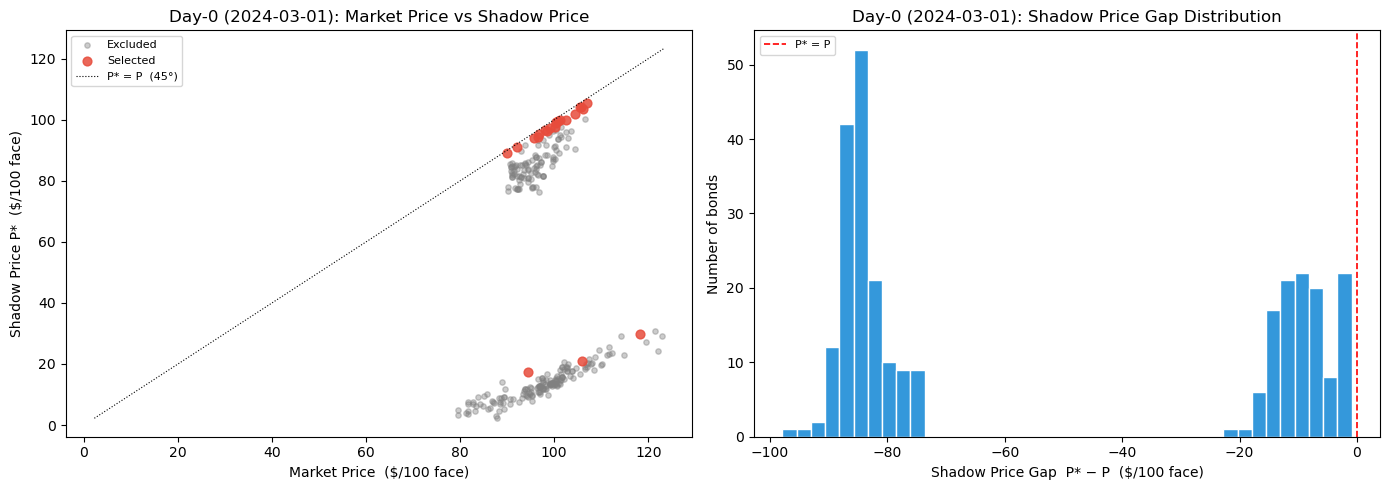


Day-0 shadow price gap stats ($/100 face):
  Mean gap   : -52.068
  Median gap : -79.344
  Max  : -0.928  (75951BAQ9)
  Min  : -97.857  (233835AQ0)


In [15]:
# =============================================================================
# 4B. PER-BOND RESERVATION PRICE — day-0 snapshot
# =============================================================================
# Re-solve the day-0 LP (from cash) to extract buy-variable reduced costs.
# On day 0, h_prev=0 and all positions are buys, so RC(b_i) = marginal value
# of buying $1 of bond i — equivalent to the optimizer's RC(h_i).
d0 = 0
date0 = BT_DATES[d0]
P = PARAMS
ymkt0 = Y[d0]; durs0 = DUR[d0]; tau0 = TAU[d0]; elig0 = ELIG[d0]
qb0, fb0, df0, PV_L0, D_FABN0, dt_q0 = quarter_slice(date0)
Q0 = len(fb0)
T0 = max((FABN_MATURITY - date0).days / 365.25, 1e-6)
lam0 = P["cost_of_capital"] * P["RBC_bar"]

use_swaps0 = P.get("use_swaps", False)
K0 = len(P.get("swap_maturities", [])) if use_swaps0 else 0
if use_swaps0 and K0 > 0:
    cf_sw0 = np.array([ff.swap_quarterly_cashflows(c, P["r_float_swap"], mat, Q0)
                       for mat, c in zip(P["swap_maturities"], P["swap_rates_k"])])

m0 = gp.Model("day0_shadow"); m0.Params.LogToConsole = 0; m0.Params.OutputFlag = 0
b0v = m0.addVars(N, lb=0.0, name="b")
for i in range(N):
    if (not elig0[i]) or (POST_FABN[i] and not P.get("allow_post_fabn", True)):
        b0v[i].ub = 0.0
dp0 = m0.addVar(lb=0.0); dn0 = m0.addVar(lb=0.0)
ep0 = m0.addVar(lb=0.0); en0 = m0.addVar(lb=0.0)
B0v = m0.addVars(Q0, lb=0.0); sn0 = m0.addVars(Q0, lb=0.0)
if use_swaps0 and K0 > 0:
    v0 = m0.addVars(K0, lb=0.0, name="v")

nii0 = gp.quicksum(b0v[i] * (ymkt0[i] - r_FABN) for i in range(N))
cap0 = gp.quicksum(theta[i] * b0v[i] for i in range(N))
trd0 = gp.quicksum(tau0[i] * b0v[i] for i in range(N))
lend0 = P["r_save"] * dt_q0 * gp.quicksum(B0v[q] for q in range(Q0))
borr0 = P["r_borrow"] * dt_q0 * gp.quicksum(sn0[q] for q in range(Q0))
if use_swaps0 and K0 > 0:
    sw_nii0 = T0 * gp.quicksum((P["swap_rates_k"][k] - P["r_float_swap"]) * v0[k] for k in range(K0))
    sw_cap0 = T0 * lam0 * P["mu_swap"] * gp.quicksum(v0[k] for k in range(K0))
else:
    sw_nii0 = 0.0; sw_cap0 = 0.0
m0.setObjective(T0*nii0 - T0*lam0*cap0 - P.get("kappa",1.0)*trd0 + lend0 - borr0
                - P.get("dur_pen",1.0)*(ep0+en0) + sw_nii0 - sw_cap0, GRB.MAXIMIZE)

m0.addConstr(gp.quicksum(b0v[i] for i in range(N)) == H)
_dsw0 = gp.quicksum(float(D_SWAP_VEC[k])*v0[k] for k in range(K0)) if (use_swaps0 and K0>0) else 0.0
m0.addConstr(gp.quicksum(durs0[i]*b0v[i] for i in range(N)) + _dsw0 - D_FABN0*H == dp0-dn0)
m0.addConstr(dp0 <= P["eps_D"]*H + ep0)
m0.addConstr(dn0 <= P["eps_D"]*H + en0)
for g, idxs in ISSUER_GROUPS.items():
    m0.addConstr(gp.quicksum(b0v[i] for i in idxs) <= P["delta_iss"]*H)
for q in range(Q0):
    cfa = gp.quicksum(qb0[q,i]*b0v[i] for i in range(N)); cfl = float(fb0[q])
    cfsw = gp.quicksum(float(cf_sw0[k,q])*v0[k] for k in range(K0)) if (use_swaps0 and K0>0) else 0.0
    if q == 0: m0.addConstr(B0v[q]-sn0[q] == cfa+cfsw-cfl)
    else:      m0.addConstr(B0v[q]-sn0[q] == (1.0+P["r_save"]*dt_q0)*B0v[q-1]+cfa+cfsw-cfl)
m0.addConstr(gp.quicksum(df0[q]*sn0[q] for q in range(Q0)) <= P["phi_sf"]*PV_L0)
if use_swaps0 and K0 > 0:
    m0.addConstr(gp.quicksum(v0[k] for k in range(K0)) <= P["swap_cap_pct"]*H)
m0.optimize()

if m0.Status == GRB.OPTIMAL:
    rc0 = np.array([b0v[i].RC for i in range(N)])
    h0_opt = np.array([b0v[i].X for i in range(N)])
    mid0 = mid_A[d0]

    r_star0 = ymkt0 - rc0
    t_q0 = np.array([dt_q0*(q+1) for q in range(Q0)])
    P_star0 = np.full(N, np.nan)
    for i in range(N):
        cfs = qb0[:, i]
        if cfs.sum() < 1e-12 or r_star0[i] <= -1:
            continue
        P_star0[i] = float((cfs * (1.0+r_star0[i])**(-t_q0)).sum()) * 100.0

    gap0 = P_star0 - mid0

    _pf0 = fixed.set_index("CUSIP")
    rows0 = []
    for i in range(N):
        if not np.isfinite(P_star0[i]) or not np.isfinite(mid0[i]) or mid0[i] <= 0:
            continue
        cid = CUSIPS[i]
        rows0.append({
            "CUSIP"             : cid,
            "Sector"            : str(_pf0.loc[cid, "sector"]),
            "Rating"            : str(_pf0.loc[cid, "rating_sp"]).strip(),
            "Mkt Price ($/100)" : round(mid0[i], 3),
            "Shadow Price P*"   : round(P_star0[i], 3),
            "Gap (P*−P)"        : round(gap0[i], 3),
            "Gap (%)"           : round(gap0[i] / mid0[i] * 100, 2),
            "Mkt Yield (%)"     : round(ymkt0[i] * 100, 3),
            "Hurdle r* (%)"     : round(r_star0[i] * 100, 3),
            "Duration (yr)"     : round(durs0[i], 3),
            "Selected"          : "YES" if h0_opt[i] > 1.0 else "",
        })
    t4b = pd.DataFrame(rows0).sort_values("Gap (P*−P)", ascending=False).reset_index(drop=True)

    n_pos = int((t4b["Gap (P*−P)"] > 0.001).sum())
    n_neg = int((t4b["Gap (P*−P)"] < -0.001).sum())
    n_par = len(t4b) - n_pos - n_neg

    print("=" * 72)
    print(f"  SECTION 4B — DAY-0 RESERVATION PRICE (SHADOW PRICE)  [{date0.date()}]")
    print("  P*_i = PV(bond CFs at hurdle yield r*_i).  Gap = P* − Market Price.")
    print("  Gap > 0 → bond is cheap for us.  Gap < 0 → bond is expensive for us.")
    print("=" * 72)
    print(f"  Bonds with P* > P (underpriced for portfolio) : {n_pos}")
    print(f"  Bonds with P* ≈ P (at the margin)            : {n_par}")
    print(f"  Bonds with P* < P (overpriced for portfolio)  : {n_neg}")
    print(f"\n  TOP 20 — highest shadow-price premium:")
    display(t4b.head(20))
    print(f"\n  BOTTOM 20 — largest shadow-price discount:")
    display(t4b.tail(20))

    elig_fin0 = np.isfinite(P_star0) & np.isfinite(mid0) & (mid0 > 0)
    P_e0  = mid0[elig_fin0]
    PS_e0 = P_star0[elig_fin0]
    sel_e0 = h0_opt[elig_fin0] > 1.0
    gap_e0 = gap0[elig_fin0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(P_e0[~sel_e0], PS_e0[~sel_e0], alpha=0.4, color="grey", s=15, label="Excluded")
    axes[0].scatter(P_e0[sel_e0],  PS_e0[sel_e0],  alpha=0.85, color="#e74c3c", s=40, label="Selected")
    _lo0 = min(P_e0.min(), PS_e0.min()) * 0.998
    _hi0 = max(P_e0.max(), PS_e0.max()) * 1.002
    axes[0].plot([_lo0, _hi0], [_lo0, _hi0], "k:", lw=0.8, label="P* = P  (45°)")
    axes[0].set_xlabel("Market Price  ($/100 face)")
    axes[0].set_ylabel("Shadow Price P*  ($/100 face)")
    axes[0].set_title(f"Day-0 ({date0.date()}): Market Price vs Shadow Price")
    axes[0].legend(fontsize=8)

    axes[1].hist(gap_e0, bins=40, color="#3498db", edgecolor="white")
    axes[1].axvline(0, color="red", ls="--", lw=1.2, label="P* = P")
    axes[1].set_xlabel("Shadow Price Gap  P* − P  ($/100 face)")
    axes[1].set_ylabel("Number of bonds")
    axes[1].set_title(f"Day-0 ({date0.date()}): Shadow Price Gap Distribution")
    axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

    print(f"\nDay-0 shadow price gap stats ($/100 face):")
    print(f"  Mean gap   : {gap_e0.mean():+.3f}")
    print(f"  Median gap : {np.median(gap_e0):+.3f}")
    print(f"  Max  : {gap_e0.max():+.3f}  ({CUSIPS[np.where(elig_fin0)[0][np.argmax(gap_e0)]]})")
    print(f"  Min  : {gap_e0.min():+.3f}  ({CUSIPS[np.where(elig_fin0)[0][np.argmin(gap_e0)]]})")
else:
    print(f"Day-0 LP status {m0.Status} — shadow prices unavailable.")

---
## Section 5 — Turnover Diagnosis & Control

The base run trades almost every day. Two LP-compatible levers to reduce this:

- **`kappa`** — multiplier on bid-ask cost in `solve_day`; widens the effective no-trade band.
- **`reopt_every`** — re-optimize every *N* trading days; hold fixed in between.

**5A** — yield pickup distribution (market yield bought vs locked yield sold).  
**5B** — shadow price time-series (which constraints bind and what they cost).  
**5C** — swap overlay time-series (daily notional, cumulative NII, net contribution).

Trade-days with both buys & sells : 496/498

Yield pickup (market bought − locked sold), bps:
count    496.000000
mean     -10.459374
std       39.024995
min     -218.154646
25%      -31.020023
50%        4.191298
75%        9.037176
max      110.274353
  share of trade-days with pickup < 1 bps : 43.5%
  share of trade-days with pickup < 2 bps : 44.6%
  share of trade-days with pickup < 5 bps : 53.2%

Mean horizon T (yrs to maturity)  : 2.52
Mean daily notional traded        : $72,273,581


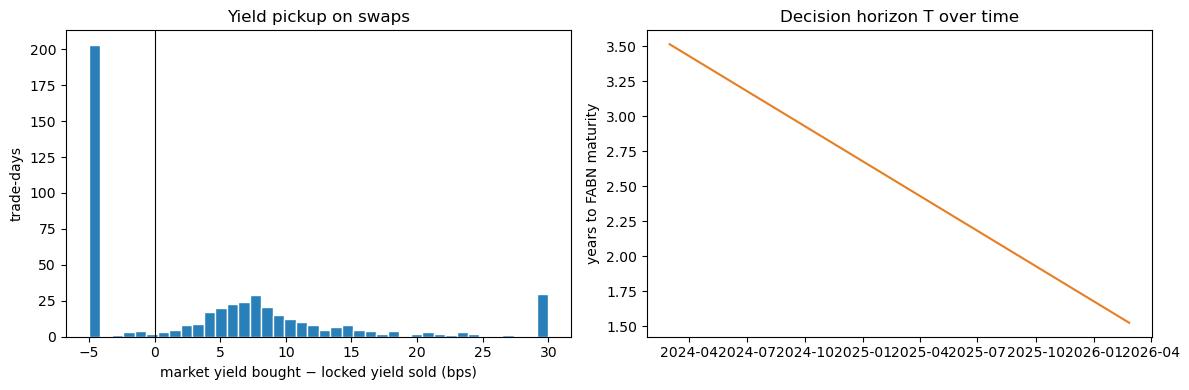

In [16]:
# =============================================================================
# 1A — Diagnose WHY the dynamic strategy trades (run on the base dyn_df)
# =============================================================================
# On every trade-day, compare the notional-weighted MARKET yield bought against
# the locked BOOK yield given up on sells. If pickups cluster near zero while the
# horizon T is large, trades are driven by tiny yield wiggles amplified by T
# beating a one-time bid-ask cost — the case for an LP no-trade band (kappa) or a
# lower rebalance frequency (reopt_every), explored in 1B below.
trd_days = dyn_df[dyn_df["pickup_bps"].notna()].copy()
print(f"Trade-days with both buys & sells : {len(trd_days)}/{nD}")
print("\nYield pickup (market bought − locked sold), bps:")
print(trd_days["pickup_bps"].describe().to_string())
for thr in (1, 2, 5):
    print(f"  share of trade-days with pickup < {thr} bps : "
          f"{(trd_days['pickup_bps'] < thr).mean()*100:.1f}%")
print(f"\nMean horizon T (yrs to maturity)  : {dyn_df['horizon_T'].mean():.2f}")
print(f"Mean daily notional traded        : ${dyn_df['traded_notional'].mean():,.0f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(trd_days["pickup_bps"].clip(-5, 30), bins=40, color="#2980b9", edgecolor="white")
ax[0].axvline(0, color="k", lw=0.8)
ax[0].set_title("Yield pickup on swaps")
ax[0].set_xlabel("market yield bought − locked yield sold (bps)")
ax[0].set_ylabel("trade-days")
ax[1].plot(dyn_df["date"], dyn_df["horizon_T"], color="#e67e22")
ax[1].set_title("Decision horizon T over time")
ax[1].set_ylabel("years to FABN maturity")
plt.tight_layout(); plt.show()

---
## Section 5B — Shadow Price Time-Series

Tracks how the LP dual values evolve day by day across the 498-day backtest.
Complements the 1A yield-pickup analysis: shadow prices explain WHY the optimizer
makes the trades it does, from the constraint side.

> **Note:** re-run Section 3 (`run_daily`) after any model change to refresh these columns.

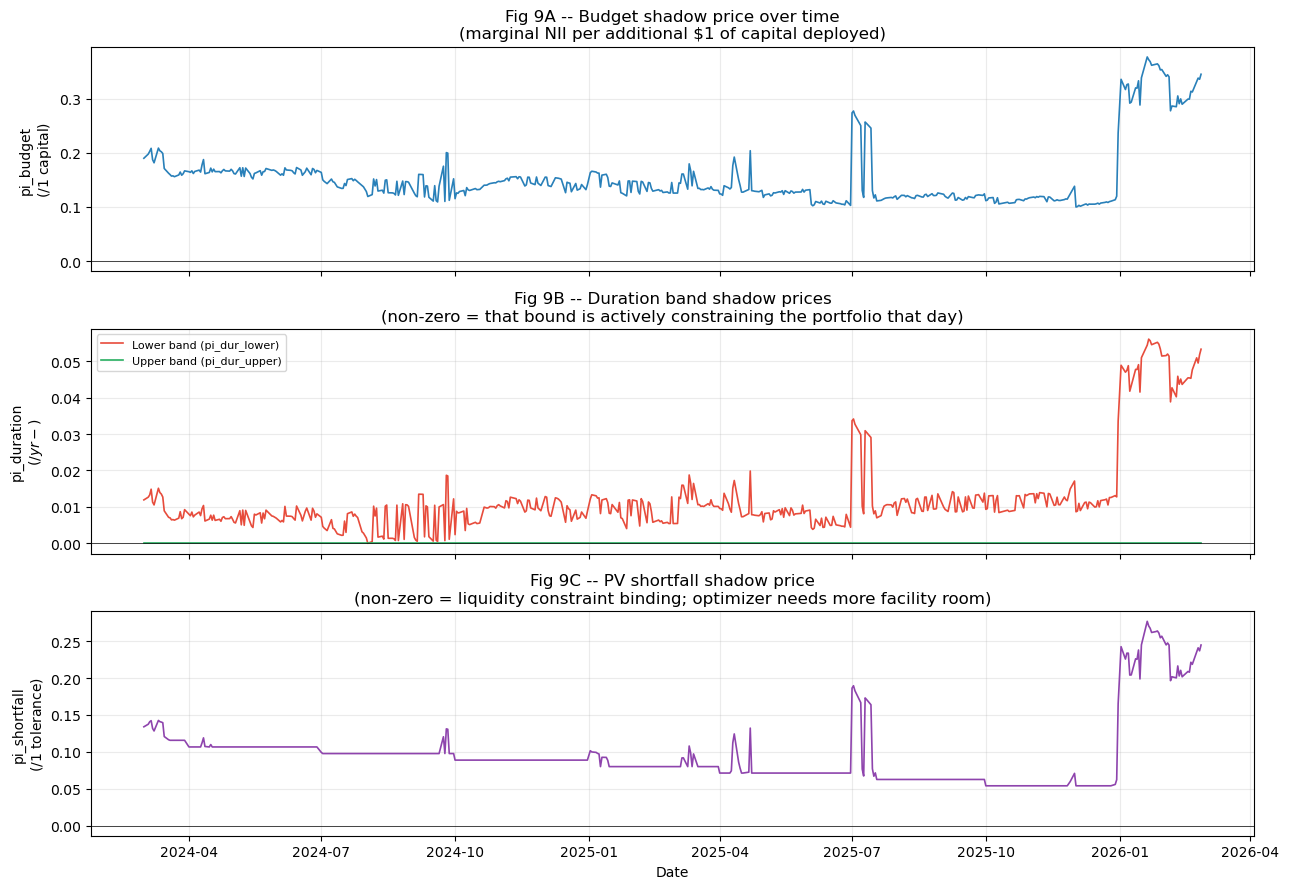

  TABLE 3 -- CONSTRAINT BINDING FREQUENCY ACROSS THE BACKTEST


,Constraint,Binding (all days %),Binding (early half %),Binding (late half %),Mean pi when binding
0,Budget,100.0%,100.0%,100.0%,$+0.1534
1,Duration upper,0.0%,0.0%,0.0%,—
2,Duration lower,99.8%,99.6%,100.0%,$+0.0124
3,PV shortfall,100.0%,100.0%,100.0%,$+0.0966


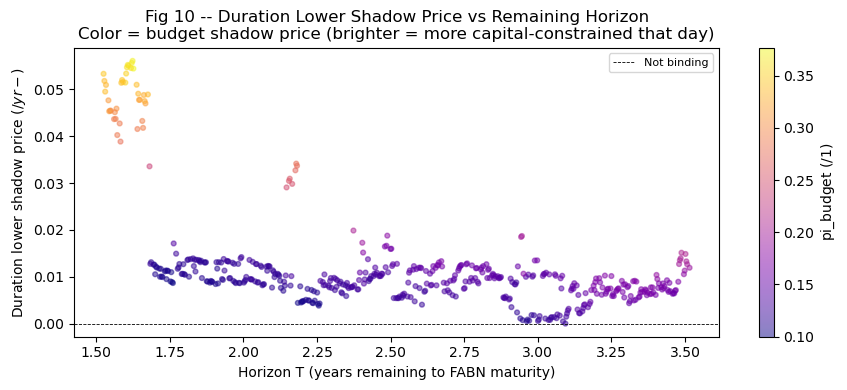


Solve days analyzed : 498  (early: 249, late: 249)
Budget pi  : mean +0.1534  [+0.0998, +0.3768]
Dur-lower pi: mean +0.0123  [+0.0000, +0.0561]
Shortfall binding on 498 / 498 solve days (100.0%).


In [17]:
# =============================================================================
# 5B. SHADOW PRICE TIME-SERIES  --  always run after Section 3 (run_daily)
# =============================================================================
if "pi_budget" not in dyn_df.columns:
    print("Shadow price columns not found -- re-run Section 3 (run_daily) first.")
else:
    solve_days = dyn_df[dyn_df["status"] == "OPTIMAL"].copy()
    n_solve    = len(solve_days)

    # ── A. Time-series of all four shadow prices ──────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

    axes[0].plot(solve_days["date"], solve_days["pi_budget"], color="#2980b9", lw=1.2)
    axes[0].axhline(0, color="k", lw=0.5); axes[0].grid(alpha=0.25)
    axes[0].set_ylabel("pi_budget\n($ / $1 capital)")
    axes[0].set_title("Fig 9A -- Budget shadow price over time\n"
                       "(marginal NII per additional $1 of capital deployed)")

    axes[1].plot(solve_days["date"], solve_days["pi_dur_lower"],
                 color="#e74c3c", lw=1.2, label="Lower band (pi_dur_lower)")
    axes[1].plot(solve_days["date"], solve_days["pi_dur_upper"],
                 color="#27ae60", lw=1.2, label="Upper band (pi_dur_upper)")
    axes[1].axhline(0, color="k", lw=0.5); axes[1].grid(alpha=0.25)
    axes[1].set_ylabel("pi_duration\n($ / yr-$)")
    axes[1].set_title("Fig 9B -- Duration band shadow prices\n"
                       "(non-zero = that bound is actively constraining the portfolio that day)")
    axes[1].legend(fontsize=8)

    axes[2].plot(solve_days["date"], solve_days["pi_shortfall"], color="#8e44ad", lw=1.2)
    axes[2].axhline(0, color="k", lw=0.5); axes[2].grid(alpha=0.25)
    axes[2].set_ylabel("pi_shortfall\n($ / $1 tolerance)")
    axes[2].set_title("Fig 9C -- PV shortfall shadow price\n"
                       "(non-zero = liquidity constraint binding; optimizer needs more facility room)")
    axes[2].set_xlabel("Date")

    plt.tight_layout(); plt.show()

    # ── B. Binding frequency: early vs late half of backtest ──────────────────
    half  = n_solve // 2
    early = solve_days.iloc[:half]
    late  = solve_days.iloc[half:]

    def _pct(col, df): return (df[col].abs() > 1e-6).mean() * 100
    def _mean_when(col, df):
        v = df.loc[df[col].abs() > 1e-6, col]
        return f"${v.mean():+,.4f}" if len(v) else "—"

    bind_df = pd.DataFrame([
        {"Constraint"                     : "Budget",
         "Binding (all days %)"           : f"{_pct('pi_budget',    solve_days):.1f}%",
         "Binding (early half %)"         : f"{_pct('pi_budget',    early):.1f}%",
         "Binding (late half %)"          : f"{_pct('pi_budget',    late):.1f}%",
         "Mean pi when binding"           : _mean_when('pi_budget',    solve_days)},
        {"Constraint"                     : "Duration upper",
         "Binding (all days %)"           : f"{_pct('pi_dur_upper', solve_days):.1f}%",
         "Binding (early half %)"         : f"{_pct('pi_dur_upper', early):.1f}%",
         "Binding (late half %)"          : f"{_pct('pi_dur_upper', late):.1f}%",
         "Mean pi when binding"           : _mean_when('pi_dur_upper', solve_days)},
        {"Constraint"                     : "Duration lower",
         "Binding (all days %)"           : f"{_pct('pi_dur_lower', solve_days):.1f}%",
         "Binding (early half %)"         : f"{_pct('pi_dur_lower', early):.1f}%",
         "Binding (late half %)"          : f"{_pct('pi_dur_lower', late):.1f}%",
         "Mean pi when binding"           : _mean_when('pi_dur_lower', solve_days)},
        {"Constraint"                     : "PV shortfall",
         "Binding (all days %)"           : f"{_pct('pi_shortfall', solve_days):.1f}%",
         "Binding (early half %)"         : f"{_pct('pi_shortfall', early):.1f}%",
         "Binding (late half %)"          : f"{_pct('pi_shortfall', late):.1f}%",
         "Mean pi when binding"           : _mean_when('pi_shortfall', solve_days)},
    ])
    print("=" * 68)
    print("  TABLE 3 -- CONSTRAINT BINDING FREQUENCY ACROSS THE BACKTEST")
    print("=" * 68)
    display(bind_df)

    # ── C. Duration lower shadow price vs remaining horizon T ─────────────────
    # Does the duration constraint bind more as the FABN approaches maturity?
    fig, ax = plt.subplots(figsize=(9, 4))
    sc = ax.scatter(
        solve_days["horizon_T"],
        solve_days["pi_dur_lower"],
        c=solve_days["pi_budget"], cmap="plasma",
        alpha=0.5, s=12,
    )
    ax.axhline(0, color="k", lw=0.6, ls="--", label="Not binding")
    ax.set_xlabel("Horizon T (years remaining to FABN maturity)")
    ax.set_ylabel("Duration lower shadow price ($ / yr-$)")
    ax.set_title("Fig 10 -- Duration Lower Shadow Price vs Remaining Horizon\n"
                 "Color = budget shadow price (brighter = more capital-constrained that day)")
    fig.colorbar(sc, ax=ax, label="pi_budget ($ / $1)")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

    print(f"\nSolve days analyzed : {n_solve}  (early: {len(early)}, late: {len(late)})")
    print(f"Budget pi  : mean {solve_days['pi_budget'].mean():+.4f}  "
          f"[{solve_days['pi_budget'].min():+.4f}, {solve_days['pi_budget'].max():+.4f}]")
    print(f"Dur-lower pi: mean {solve_days['pi_dur_lower'].mean():+.4f}  "
          f"[{solve_days['pi_dur_lower'].min():+.4f}, {solve_days['pi_dur_lower'].max():+.4f}]")
    n_sf = int((solve_days["pi_shortfall"].abs() > 1e-6).sum())
    print(f"Shortfall binding on {n_sf} / {n_solve} solve days ({n_sf/n_solve*100:.1f}%).")

---
## Section 5C — Swap Overlay: Backtest Time-Series

How the swap overlay evolved across the backtest horizon.


Days with swap active   : 498 / 498 solve days (100%)
Avg swap notional (active days): $100.0M
Total swap NII (cumulative)    : $0.299M
Total swap cap cost (cumul.)   : $0.048M
Net swap contribution          : $0.251M


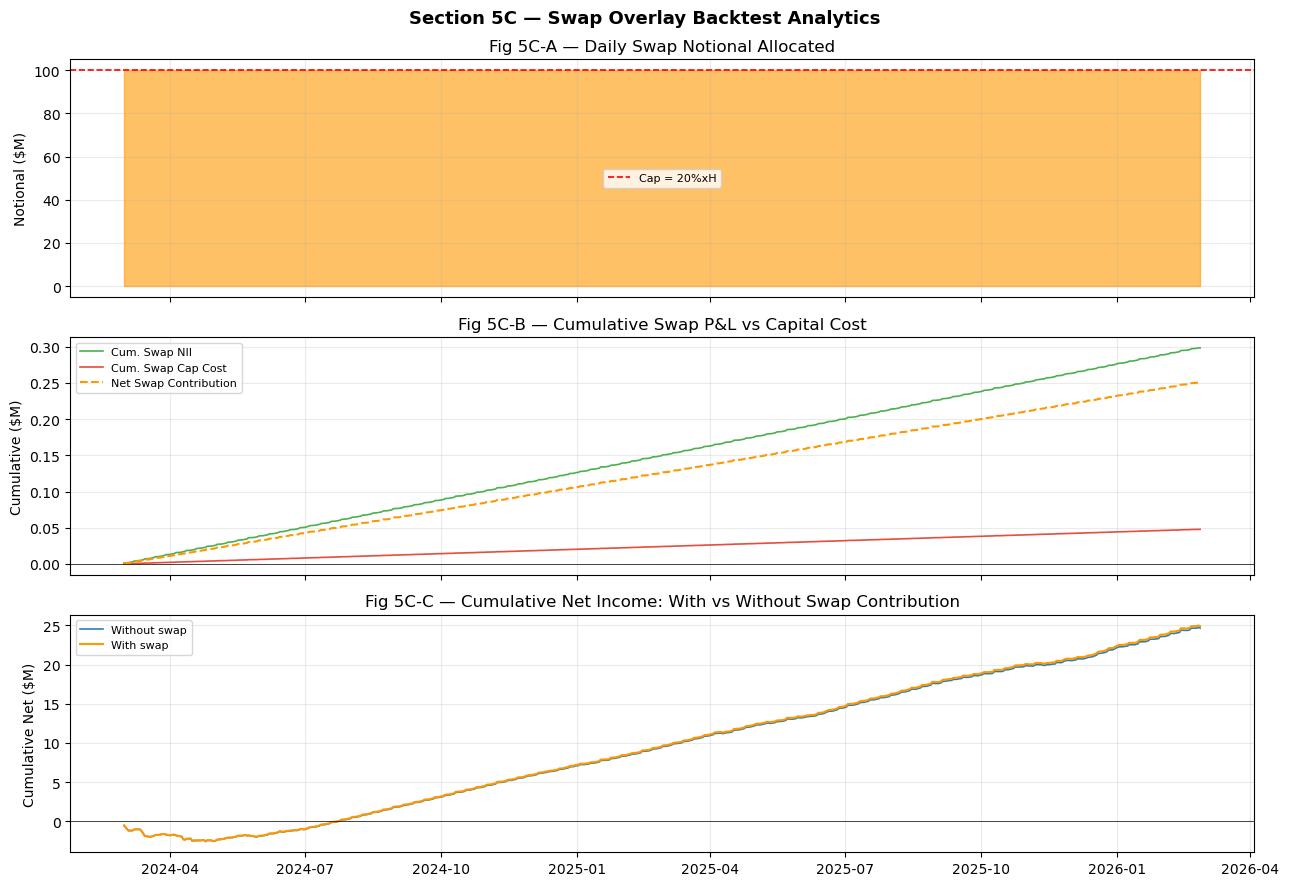

Saved: fig_backtest_swap.png


In [18]:
# =============================================================================
# 5C. SWAP OVERLAY TIME-SERIES  --  always run after Section 3
# =============================================================================
if "swap_notional" not in dyn_df.columns:
    print("Swap columns not found -- re-run Section 3 (run_daily) first.")
else:
    solve_d = dyn_df[dyn_df["status"] == "OPTIMAL"].copy()
    swap_d  = solve_d[solve_d["swap_notional"] > 1.0]

    print(f"Days with swap active   : {len(swap_d)} / {len(solve_d)} solve days "
          f"({len(swap_d)/len(solve_d):.0%})")
    print(f"Avg swap notional (active days): ${solve_d['swap_notional'].mean()/1e6:.1f}M")
    print(f"Total swap NII (cumulative)    : ${dyn_df['swap_nii_day'].sum()/1e6:.3f}M")
    print(f"Total swap cap cost (cumul.)   : ${dyn_df['swap_cap_day'].sum()/1e6:.3f}M")
    print(f"Net swap contribution          : ${(dyn_df['swap_nii_day']-dyn_df['swap_cap_day']).sum()/1e6:.3f}M")

    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

    # 5C-A: swap notional over time
    axes[0].fill_between(solve_d["date"], solve_d["swap_notional"] / 1e6,
                         alpha=0.6, color="#FF9800")
    axes[0].axhline(PARAMS["swap_cap_pct"] * H / 1e6, color="red", lw=1.2,
                    linestyle="--", label=f"Cap = {PARAMS['swap_cap_pct']:.0%}xH")
    axes[0].set_ylabel("Notional ($M)")
    axes[0].set_title("Fig 5C-A — Daily Swap Notional Allocated")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)

    # 5C-B: cumulative swap NII vs swap capital cost
    cum_swap_nii = dyn_df["swap_nii_day"].cumsum()
    cum_swap_cap = dyn_df["swap_cap_day"].cumsum()
    cum_swap_net = (dyn_df["swap_nii_day"] - dyn_df["swap_cap_day"]).cumsum()
    axes[1].plot(dyn_df["date"], cum_swap_nii / 1e6, color="#4CAF50", lw=1.2, label="Cum. Swap NII")
    axes[1].plot(dyn_df["date"], cum_swap_cap / 1e6, color="#e74c3c", lw=1.2, label="Cum. Swap Cap Cost")
    axes[1].plot(dyn_df["date"], cum_swap_net / 1e6, color="#FF9800", lw=1.5,
                 linestyle="--", label="Net Swap Contribution")
    axes[1].axhline(0, color="k", lw=0.5)
    axes[1].set_ylabel("Cumulative ($M)")
    axes[1].set_title("Fig 5C-B — Cumulative Swap P&L vs Capital Cost")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.25)

    # 5C-C: net income with and without swap contribution
    cum_net_noswap = (dyn_df["NII"] - dyn_df["Capital"] - dyn_df["Turnover"] + dyn_df["IMR_release"]).cumsum()
    cum_net_swap   = dyn_df["Net"].cumsum()
    axes[2].plot(dyn_df["date"], cum_net_noswap / 1e6, color="#2980b9", lw=1.2, label="Without swap")
    axes[2].plot(dyn_df["date"], cum_net_swap   / 1e6, color="#FF9800", lw=1.5, label="With swap")
    axes[2].axhline(0, color="k", lw=0.5)
    axes[2].set_ylabel("Cumulative Net ($M)")
    axes[2].set_title("Fig 5C-C — Cumulative Net Income: With vs Without Swap Contribution")
    axes[2].legend(fontsize=8); axes[2].grid(alpha=0.25)

    plt.suptitle("Section 5C — Swap Overlay Backtest Analytics", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig_backtest_swap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig_backtest_swap.png")


Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set paramete

,kappa,reopt_every,dyn_net,adv_vs_static,turnover,notional,trade_days,adv_%
0,10,5,3.580610e+07,6.599270e+06,2.522199e+06,6.699822e+09,93,22.594954
1,10,1,3.557869e+07,6.371858e+06,3.307476e+06,1.162187e+10,466,21.816328
2,5,5,3.471925e+07,5.512418e+06,4.066455e+06,9.280997e+09,100,18.873728
3,5,21,3.471258e+07,5.505756e+06,2.209748e+06,4.004845e+09,24,18.850919
4,2,21,3.461279e+07,5.405958e+06,2.861634e+06,4.727691e+09,24,18.509224
5,10,21,3.458593e+07,5.379098e+06,1.683205e+06,3.553915e+09,23,18.417262
6,1,21,3.452137e+07,5.314546e+06,3.199869e+06,5.146758e+09,24,18.196243
7,5,1,3.402310e+07,4.816275e+06,5.598334e+06,1.734684e+10,498,16.490235
8,1,63,3.401908e+07,4.812249e+06,1.831871e+06,2.486867e+09,8,16.476450
9,2,63,3.392931e+07,4.722483e+06,1.777205e+06,2.377728e+09,8,16.169106


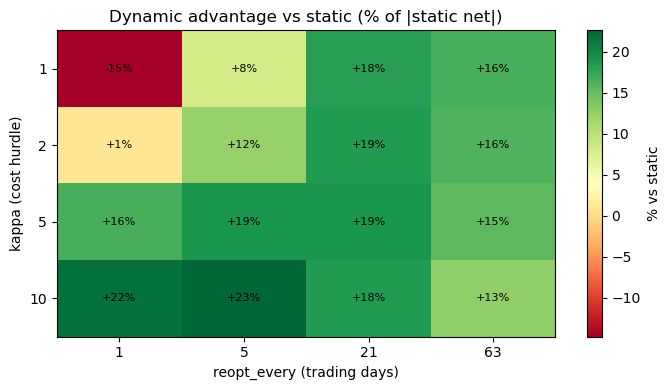

In [19]:
# =============================================================================
# 1B — Turnover levers: kappa (LP cost hurdle) × reopt_every (rebalance frequency)
# =============================================================================
# Static is the same baseline for every cell (solve once on day 0, then hold).
# Each dynamic run is a full daily backtest, so this is ~16 backtests — a few
# minutes at STEP=1. Lower the grid or raise STEP for a quick trial.
import itertools

sta_total = sta_df["Net"].sum()
_den = abs(sta_total) if abs(sta_total) > 1.0 else float("nan")   # guard divide-by-zero
_rows = []
for _kappa, _every in itertools.product([1, 2, 5, 10], [1, 5, 21, 63]):
    _P = dict(PARAMS, kappa=_kappa)
    _df, _ = run_daily(dynamic=True, reopt_every=_every, params=_P)
    _dyn = _df["Net"].sum()
    _rows.append(dict(kappa=_kappa, reopt_every=_every, dyn_net=_dyn,
                      adv_vs_static=_dyn - sta_total,
                      turnover=_df["Turnover"].sum(),
                      notional=_df["traded_notional"].sum(),
                      trade_days=int((_df["n_trades"] > 0).sum())))
    print(f"  kappa={_kappa:<2} reopt_every={_every:<2} -> dyn ${_dyn/1e6:6.2f}M "
          f"(vs static {(_dyn-sta_total)/_den*100:+.1f}%)  turnover ${_df['Turnover'].sum()/1e6:.2f}M")

sweep = pd.DataFrame(_rows)
sweep["adv_%"] = sweep["adv_vs_static"] / _den * 100
print(f"\nSTATIC baseline net = ${sta_total:,.0f}"
      + ("" if abs(sta_total) > 1.0 else "   <-- ~0, so adv_% is n/a; compare dyn_net directly"))
display(sweep.sort_values("dyn_net", ascending=False).reset_index(drop=True))

# Heatmap: dynamic advantage vs static across the lever grid
piv = sweep.pivot(index="kappa", columns="reopt_every", values="adv_%")
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(piv.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
ax.set_xlabel("reopt_every (trading days)"); ax.set_ylabel("kappa (cost hurdle)")
ax.set_title("Dynamic advantage vs static (% of |static net|)")
for (i, j), v in np.ndenumerate(piv.values):
    ax.text(j, i, f"{v:+.0f}%" if np.isfinite(v) else "n/a", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="% vs static"); plt.tight_layout(); plt.show()

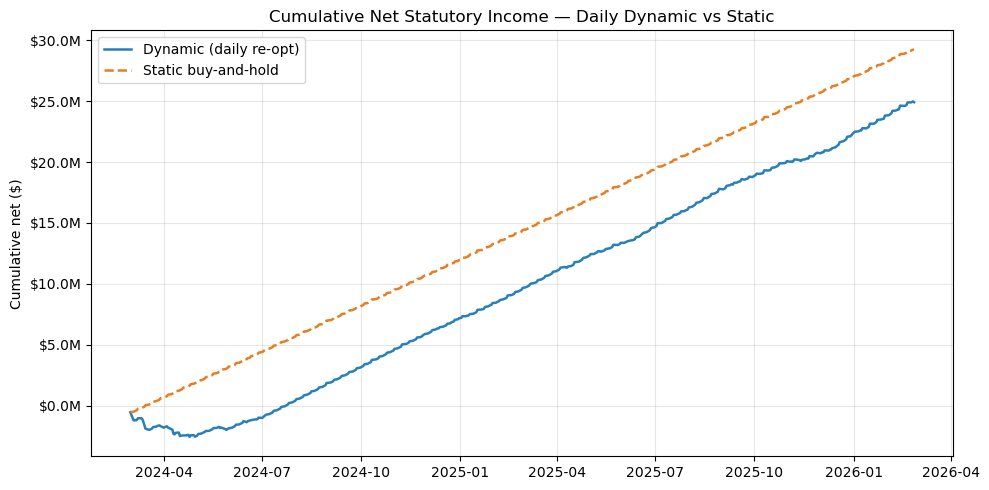

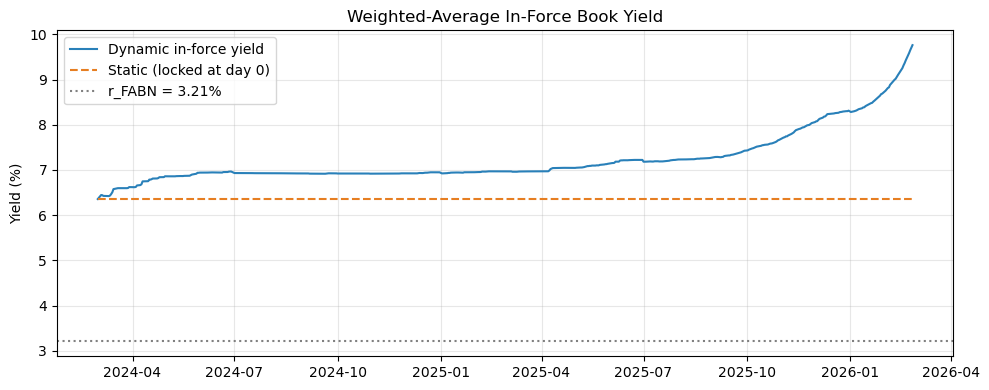

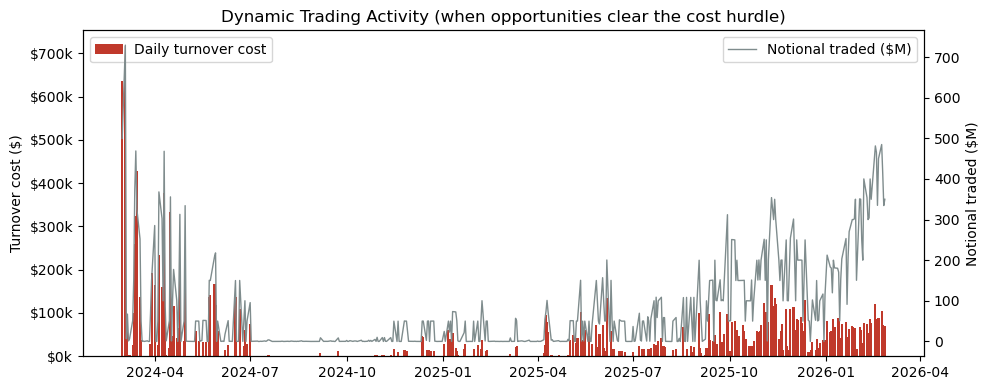

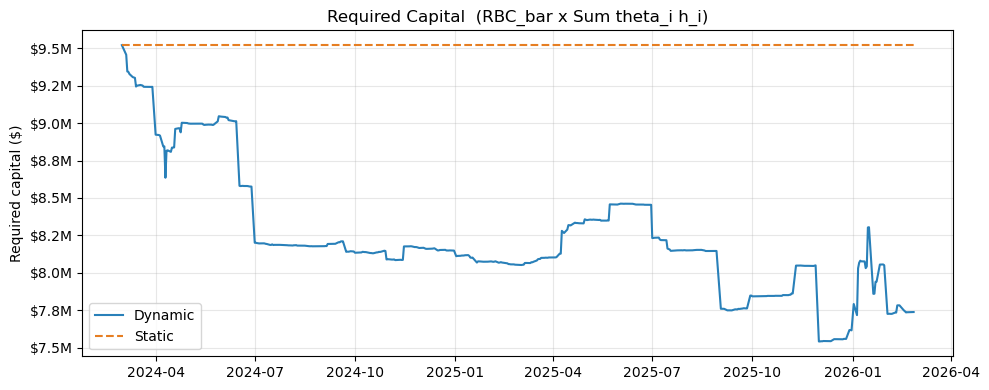

In [20]:
# Fig 1: cumulative net statutory income, dynamic vs static
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(dyn_df["date"], dyn_df["CumNet"], color="#2980b9", lw=1.8, label="Dynamic (daily re-opt)")
ax.plot(sta_df["date"], sta_df["CumNet"], color="#e67e22", lw=1.8, ls="--", label="Static buy-and-hold")
ax.set_title("Cumulative Net Statutory Income — Daily Dynamic vs Static")
ax.set_ylabel("Cumulative net ($)"); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"${v/1e6:.1f}M"))
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Fig 2: in-force weighted book yield over time
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(dyn_df["date"], dyn_df["wavg_book_yield"]*100, color="#2980b9", lw=1.5, label="Dynamic in-force yield")
ax.plot(sta_df["date"], sta_df["wavg_book_yield"]*100, color="#e67e22", lw=1.5, ls="--", label="Static (locked at day 0)")
ax.axhline(r_FABN*100, color="grey", ls=":", label=f"r_FABN = {r_FABN*100:.2f}%")
ax.set_title("Weighted-Average In-Force Book Yield"); ax.set_ylabel("Yield (%)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Fig 3: daily turnover paid + trade count (dynamic)
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(dyn_df["date"], dyn_df["Turnover"], width=2.0, color="#c0392b", label="Daily turnover cost")
ax.set_ylabel("Turnover cost ($)"); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"${v/1e3:.0f}k"))
ax2 = ax.twinx(); ax2.plot(dyn_df["date"], dyn_df["traded_notional"]/1e6, color="#7f8c8d", lw=1, label="Notional traded ($M)")
ax2.set_ylabel("Notional traded ($M)")
ax.set_title("Dynamic Trading Activity (when opportunities clear the cost hurdle)")
ax.legend(loc="upper left"); ax2.legend(loc="upper right"); plt.tight_layout(); plt.show()

# Fig 4: required capital over time
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(dyn_df["date"], dyn_df["req_capital"], color="#2980b9", lw=1.5, label="Dynamic")
ax.plot(sta_df["date"], sta_df["req_capital"], color="#e67e22", lw=1.5, ls="--", label="Static")
ax.set_title("Required Capital  (RBC_bar x Sum theta_i h_i)"); ax.set_ylabel("Required capital ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"${v/1e6:.1f}M"))
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## Section 6 — IMR: Completing the Picture

Sections 3–5 are **conservative** — sale gains are never recognized. **IMR** fixes this the SAP-correct way: a rate-driven realized gain/loss enters the **Interest Maintenance Reserve** and is **amortized into income over the sold bond's remaining life** — never booked at the sale date.

IMR is an *accounting consequence* — `solve_day` is unchanged; it only re-times income recognition.

Two dynamic scenarios compared against static:
- **BASE** — `kappa=1, reopt_every=1`: daily rebalancing at full bid-ask (worst case).
- **TUNED** — `reopt_every=21, kappa=2`: monthly rebalancing with cost hurdle (realistic operating point).

For each: no-IMR, IMR released in-window, and IMR fully recognized. Static never sells → its line is unchanged.

Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set paramete

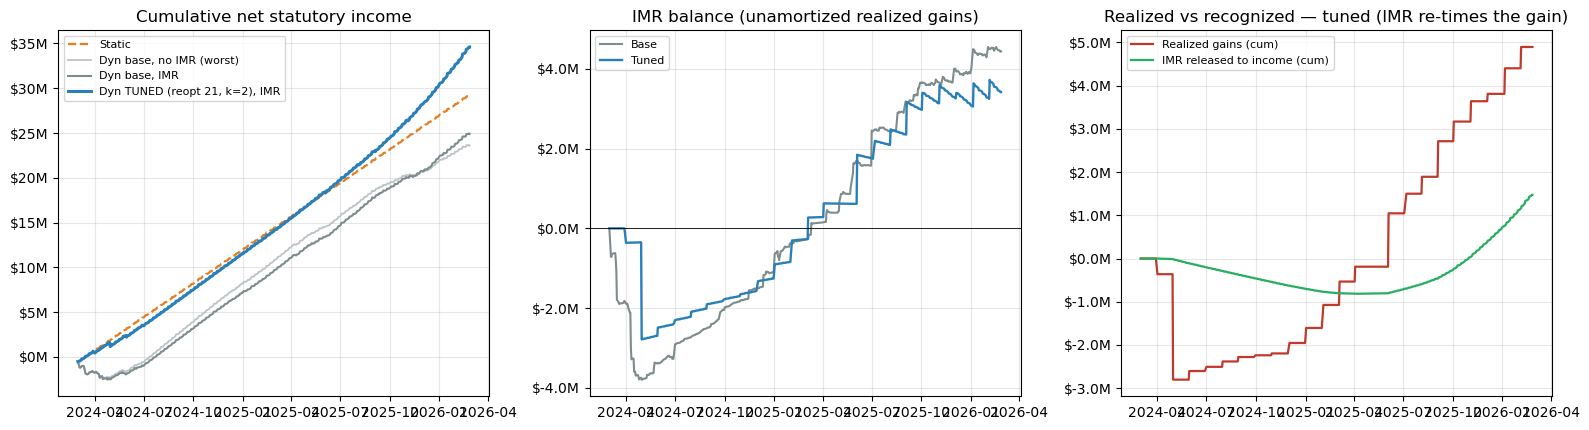

In [21]:
# =============================================================================
# Section 6 — IMR: recognizing realized gains/losses on sales (gradually)
# =============================================================================
# IMR is an accounting CONSEQUENCE; it does not change solve_day's decision. We
# show TWO dynamic scenarios so the picture isn't judged only on the worst cell:
#   * BASE  = PARAMS (kappa=1, reopt_every=1) -> daily, full bid-ask = WORST case.
#   * TUNED = a realistic operating point (monthly rebalance + a modest hurdle).
# For each: no-IMR (coupons only) vs with-IMR (rate-driven sale gains amortized
# over the sold bond's remaining life). Static never sells -> IMR ~ 0, unchanged.
TUNED_REOPT, TUNED_KAPPA = 21, 2
TUNED = dict(PARAMS, kappa=TUNED_KAPPA)

dyn_noimr_df, _       = run_daily(dynamic=True, use_imr=False)                                        # base, no IMR
dyn_tuned_df, _       = run_daily(dynamic=True, reopt_every=TUNED_REOPT, params=TUNED, use_imr=True)  # tuned, IMR
dyn_tuned_noimr_df, _ = run_daily(dynamic=True, reopt_every=TUNED_REOPT, params=TUNED, use_imr=False) # tuned, no IMR

sta_net = sta_df["Net"].sum()
def _summ(df):
    net = df["Net"].sum()
    rem = df["IMR_balance"].iloc[-1] if "IMR_balance" in df else 0.0
    return net, net + rem
_p = lambda x: f"{(x-sta_net)/abs(sta_net)*100:+5.1f}% vs static"

bn, _      = _summ(dyn_noimr_df)            # base, no IMR
b_in, b_fl = _summ(dyn_df)                  # base, IMR (dyn_df runs with use_imr=True)
tn, _      = _summ(dyn_tuned_noimr_df)      # tuned, no IMR
t_in, t_fl = _summ(dyn_tuned_df)            # tuned, IMR

print("="*80)
print(f"  STATIC                                              : ${sta_net:,.0f}")
print(f"  -- BASE  (daily re-opt, kappa=1)  = WORST case ---------------------------------")
print(f"  Dynamic, no IMR                                     : ${bn:,.0f}  ({_p(bn)})")
print(f"  Dynamic, IMR in-window                              : ${b_in:,.0f}  ({_p(b_in)})")
print(f"  Dynamic, IMR fully recognized                       : ${b_fl:,.0f}  ({_p(b_fl)})")
print(f"  -- TUNED (reopt_every={TUNED_REOPT}, kappa={TUNED_KAPPA}) = realistic pacing ---------------------")
print(f"  Dynamic, no IMR                                     : ${tn:,.0f}  ({_p(tn)})")
print(f"  Dynamic, IMR in-window                              : ${t_in:,.0f}  ({_p(t_in)})")
print(f"  Dynamic, IMR fully recognized                       : ${t_fl:,.0f}  ({_p(t_fl)})")
print("-"*80)
print(f"  Gains harvested   base ${dyn_df['realized_gain'].sum():,.0f} | tuned ${dyn_tuned_df['realized_gain'].sum():,.0f}")
print(f"  Turnover paid     base ${dyn_df['Turnover'].sum():,.0f} | tuned ${dyn_tuned_df['Turnover'].sum():,.0f}")
print("="*80)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
# (1) cumulative net — static vs base(no-IMR, worst) vs base(IMR) vs TUNED(IMR)
ax[0].plot(sta_df["date"], sta_df["CumNet"], color="#e67e22", ls="--", lw=1.6, label="Static")
ax[0].plot(dyn_noimr_df["date"], dyn_noimr_df["CumNet"], color="#bdc3c7", lw=1.3, label="Dyn base, no IMR (worst)")
ax[0].plot(dyn_df["date"], dyn_df["CumNet"], color="#7f8c8d", lw=1.5, label="Dyn base, IMR")
ax[0].plot(dyn_tuned_df["date"], dyn_tuned_df["CumNet"], color="#2980b9", lw=2.2,
           label=f"Dyn TUNED (reopt {TUNED_REOPT}, k={TUNED_KAPPA}), IMR")
ax[0].set_title("Cumulative net statutory income"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.0f}M"))
# (2) IMR balance over time — base vs tuned
ax[1].plot(dyn_df["date"], dyn_df["IMR_balance"], color="#7f8c8d", lw=1.5, label="Base")
ax[1].plot(dyn_tuned_df["date"], dyn_tuned_df["IMR_balance"], color="#2980b9", lw=1.7, label="Tuned")
ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_title("IMR balance (unamortized realized gains)"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))
# (3) realized vs recognized (tuned) — IMR re-times the gain into income
ax[2].plot(dyn_tuned_df["date"], dyn_tuned_df["realized_gain"].cumsum(), color="#c0392b", lw=1.6, label="Realized gains (cum)")
ax[2].plot(dyn_tuned_df["date"], dyn_tuned_df["IMR_release"].cumsum(), color="#27ae60", lw=1.6, label="IMR released to income (cum)")
ax[2].set_title("Realized vs recognized — tuned (IMR re-times the gain)"); ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
ax[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))
plt.tight_layout(); plt.show()

---
## Notes

- **Runtime:** the IRR precompute (Section 1) is the slow step; set `STEP > 1` for a faster trial run.
- **Soft duration band:** breach beyond ±`eps_D` is penalized, not forbidden — the LP stays feasible even when the hard band is unreachable early in the horizon.
- **IMR scope:** interest-rate-driven realized gains/losses only. AVR (credit/default reserve) remains out of scope.